# Financial Sentiment Analysis - Algorithm Comparison

**Dataset:** Financial PhraseBank + FiQA — 8,496 unique samples after deduplication, downsampled to **8,100 balanced samples** (2,700 per class)

**Algorithms Tested:** SVM, Random Forest, XGBoost, MLP, Naive Bayes, RNN, LSTM, GRU and FinBERT

**Goal:** Compare traditional ML, recurrent neural networks and a transformer on financial sentiment classification, under identical preprocessing

**Note on the numbers:** every result table and figure in this notebook is computed from the models when the notebook runs. None of them are typed in. The neural networks are seeded, so the whole notebook reproduces.


## Project Overview: Comprehensive ML Algorithm Testing for Financial Sentiment Analysis

### Context

This project empirically tests machine learning algorithms for financial sentiment classification to determine which performs best with clean, balanced data.

**Purpose:** Algorithm selection for production deployment based on evidence, not theory.

---

### Research Gap

Previous research on Financial PhraseBank has tested:
- Logistic Regression: 70.06% accuracy (Mayank Pujara)
- Naive Bayes: 62% accuracy (Muhamed Ahmed)  
- RNN: 77% accuracy (Muhamed Ahmed)
- LSTM: 79.8% accuracy (Muhamed Ahmed)
- GRU: 80.6% accuracy (Muhamed Ahmed)

**However:** These studies used data with duplicates and inconsistent preprocessing, potentially inflating neural network results.

---

### My Research Contribution

**Comprehensive Testing:** 9 algorithms tested on clean, balanced data

**Traditional ML (4 algorithms):**
1. **Support Vector Machine (SVM)** - High-dimensional text specialist
2. **Random Forest** - Robust ensemble baseline  
3. **Gradient Boosting (XGBoost)** - Competition-winning ensemble
4. **Multi-Layer Perceptron (MLP)** - Simple neural network

**Simple Baseline (1 algorithm):**

5. **Naive Bayes** - Probability-based classifier

**Recurrent Neural Networks (3 algorithms):**

6. **RNN** - Basic recurrent neural network, no gating
7. **LSTM** - Long Short-Term Memory, three gates
8. **GRU** - Gated Recurrent Unit, two gates

**Transformer (1 algorithm):**

9. **FinBERT** - BERT pre-trained on financial text, used zero-shot (no fine-tuning).
   A second variant, FinBERT-Tone, is also tested.

---

### Dataset Journey

**Sources:** Financial PhraseBank (5,842 sentences, imbalanced) combined with FiQA, giving
**9,000 rows** before cleaning.

**Data Quality Issues Discovered:**
- 504 duplicate sentences (5.6% of the combined data)
- Same sentences with conflicting labels (e.g. the same text labelled both "negative" and "neutral")
- Class imbalance (54% neutral, 32% positive, 14% negative)

**My Data Cleaning Process:**
1. Removed the 504 duplicates → **8,496 unique samples** (9,000 − 504)
2. Downsampled each class to 2,700 → **8,100 final samples**
3. Exact balance: 33.3% negative, 33.3% neutral, 33.3% positive
4. Downsampled rather than upsampled, because upsampling reintroduces duplicates

**Final Dataset:**
- **Total samples:** 8,100 (clean, balanced, no duplicates)
- **Sentiment distribution:** 2,700 negative | 2,700 neutral | 2,700 positive
- **Sources:** Financial PhraseBank + FiQA (manually curated)
- **Quality:** All duplicates removed, perfectly balanced classes

---

### Key Differentiator

**Most studies:** Use data as-is (including duplicates) or upsample (create more duplicates)

**My approach:** Remove duplicates entirely for honest evaluation of algorithm performance on unique data

# Import all libraries

In [1]:
import pandas as pd # Load and manipulate data
import re # Regular expressions for text cleaning
import string # String operations
import numpy as np # Numerical operations
import matplotlib.pyplot as plt # Data visualization
import time # Measure execution time
import seaborn as sns # Statistical data visualization
import nltk # Natural Language Processing
from sklearn.ensemble import RandomForestClassifier # Random Forest model
from sklearn.utils import resample # Resampling for balancing dataset
from xgboost import XGBClassifier # XGBoost model
from sklearn.svm import SVC # Support Vector Machine model
from sklearn.neural_network import MLPClassifier # Neural Network model
from string import punctuation # Punctuation characters
from nltk.corpus import stopwords # Stopwords for text processing
from nltk.tokenize import word_tokenize # Tokenization
from nltk.stem import WordNetLemmatizer # Lemmatization 
from sklearn.preprocessing import LabelEncoder # Label encoding
from sklearn.model_selection import train_test_split # Train-test split
from sklearn.feature_extraction.text import TfidfVectorizer # TF-IDF vectorization
from sklearn.feature_extraction.text import CountVectorizer # Count vectorization, used by Naive Bayes
from sklearn.naive_bayes import GaussianNB # Naive Bayes model
from sklearn.metrics import accuracy_score, classification_report
%matplotlib inline 

# NLTK downloads

In [2]:
# Download required NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/user/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/user/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /home/user/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/user/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Load data_cleaned.csv after previously cleaning data for duplicates

In [3]:
# Load the CLEANED dataset
df = pd.read_csv('data_cleaned.csv')

print("Cleaned dataset loaded:")
print(f"Total rows: {len(df)}")
print("\nSentiment distribution:")
print(df['Sentiment'].value_counts().sort_index())

Cleaned dataset loaded:
Total rows: 8496

Sentiment distribution:
Sentiment
negative    2727
neutral     2770
positive    2999
Name: count, dtype: int64


# Downsample to 2,700 Each to balance the data

In [4]:
print("="*60)
print("BALANCING DATASET")
print("="*60)

print(f"\nBefore balancing:")
print(df['Sentiment'].value_counts().sort_index())

# Separate by sentiment
df_negative = df[df['Sentiment'] == 'negative']
df_neutral = df[df['Sentiment'] == 'neutral']
df_positive = df[df['Sentiment'] == 'positive']

# Downsample all to 2,700 each
df_negative_downsampled = resample(df_negative, 
                                   replace=False,
                                   n_samples=2700,
                                   random_state=42)

df_neutral_downsampled = resample(df_neutral,
                                  replace=False,
                                  n_samples=2700,
                                  random_state=42)

df_positive_downsampled = resample(df_positive,
                                   replace=False,
                                   n_samples=2700,
                                   random_state=42)

# Combine into final balanced dataset
df = pd.concat([df_negative_downsampled, 
                df_neutral_downsampled, 
                df_positive_downsampled])

# Shuffle to mix sentiments
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nAfter balancing:")
print(df['Sentiment'].value_counts().sort_index())
print(f"\nFinal dataset size: {len(df)} samples")
print("✅ Dataset is now perfectly balanced!")

BALANCING DATASET

Before balancing:
Sentiment
negative    2727
neutral     2770
positive    2999
Name: count, dtype: int64

After balancing:
Sentiment
negative    2700
neutral     2700
positive    2700
Name: count, dtype: int64

Final dataset size: 8100 samples
✅ Dataset is now perfectly balanced!


# Text preprocessing & Feature Extraction

Cleaning and preparing text data for ML algorithms:
1. Lowercase conversion
2. Remove special characters and punctuation
3. Tokenisation
4. Remove stopwords
5. Lemmatisation
6. Label encoding for sentiment classes

# Define Preprocessing Function

In [5]:
# Initialize preprocessing tools
stop_words = stopwords.words('english')
lzr = WordNetLemmatizer()

# Define preprocessing function
def text_processing(text):   
    # convert text into lowercase
    text = text.lower()

    # remove new line characters in text
    text = re.sub(r'\n',' ', text)
    
    # remove punctuations from text
    text = re.sub('[%s]' % re.escape(punctuation), "", text)
    
    # remove references and hashtags from text
    text = re.sub("^a-zA-Z0-9$,.", "", text)
    
    # remove multiple spaces from text
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    
    # remove special characters from text
    text = re.sub(r'\W', ' ', text)
    
    # tokenize the words using nltk word tokenizer and remove the stop words
    text = ' '.join([word for word in word_tokenize(text) if word not in stop_words])
    
    # lemmatizer using WordNetLemmatizer from nltk package
    text = ' '.join([lzr.lemmatize(word) for word in word_tokenize(text)])

    return text

# Apply Preprocessing to the Data

In [6]:
# Create a copy of the original dataframe
data_copy = df.copy()

# Apply preprocessing to all sentences
data_copy['Sentence'] = data_copy['Sentence'].apply(lambda text: text_processing(text))

# Display first few rows to see the cleaned text
print("Preprocessed sentences:")
print(data_copy.head())

Preprocessed sentences:
                                            Sentence Sentiment
0          total value agreement usd4 0 company said   neutral
1  manappuram finance ltd record 46 rise net prof...  positive
2  kwality among cheapest play dairy sector ashis...  positive
3                        operating margin came 24 57   neutral
4                          educomp buy deepak mohoni  positive


# Label Encoding

In [7]:
# Encode sentiment labels to numbers
le = LabelEncoder()
data_copy['Sentiment'] = le.fit_transform(data_copy['Sentiment'])

# Display the encoded sentiments
print("Label encoding mapping:")
print("Classes:", le.classes_)
print("\nFirst few rows with encoded sentiments:")
print(data_copy.head())

print("\nSentiment distribution after encoding:")
print(data_copy['Sentiment'].value_counts().sort_index())

Label encoding mapping:
Classes: ['negative' 'neutral' 'positive']

First few rows with encoded sentiments:
                                            Sentence  Sentiment
0          total value agreement usd4 0 company said          1
1  manappuram finance ltd record 46 rise net prof...          2
2  kwality among cheapest play dairy sector ashis...          2
3                        operating margin came 24 57          1
4                          educomp buy deepak mohoni          2

Sentiment distribution after encoding:
Sentiment
0    2700
1    2700
2    2700
Name: count, dtype: int64


# TF-IDF Vectorisation

Converting cleaned text into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency).

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(data_copy['Sentence'])
y = data_copy['Sentiment']

print("Shape of feature matrix (X):", X.shape)
print("Shape of labels (y):", y.shape)
print("\nFirst sentence vectorized:")
print("Non-zero features:", X[0].nnz)  # Number of non-zero features in first sentence ```

Shape of feature matrix (X): (8100, 5000)
Shape of labels (y): (8100,)

First sentence vectorized:
Non-zero features: 5


# Train/Test Split

Splitting data into 80% training and 20% testing sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:")
print("  X_train shape:", X_train.shape)
print("  y_train shape:", y_train.shape)
print("\nTesting set:")
print("  X_test shape:", X_test.shape)
print("  y_test shape:", y_test.shape)

# Check class distribution in train/test
print("\nTraining set sentiment distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nTesting set sentiment distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set:
  X_train shape: (6480, 5000)
  y_train shape: (6480,)

Testing set:
  X_test shape: (1620, 5000)
  y_test shape: (1620,)

Training set sentiment distribution:
Sentiment
0    2152
1    2152
2    2176
Name: count, dtype: int64

Testing set sentiment distribution:
Sentiment
0    548
1    548
2    524
Name: count, dtype: int64


# Algorithms 1-4: Classical Machine Learning

The first four models all take the same TF-IDF features built above:

1. Support Vector Machine (SVM)
2. Random Forest
3. XGBoost (Gradient Boosting)
4. Multi-Layer Perceptron (MLP)

Each is evaluated on accuracy, precision, recall, F1-score, training time and prediction time.


# Algorithm 1 SVM

In [10]:
# Initialize SVM
print("Training SVM...")
svm_model = SVC(random_state=42)

# Train and measure time
start_time = time.time()
svm_model.fit(X_train, y_train)
training_time = time.time() - start_time

# Predict and measure time
start_time = time.time()
svm_predictions = svm_model.predict(X_test)
prediction_time = time.time() - start_time

# Evaluate
svm_accuracy = accuracy_score(y_test, svm_predictions)
# Keep this model's own timings so the summary table can be computed, not typed.
svm_training_time = training_time
svm_prediction_time = prediction_time

print(f"\n=== SVM Results ===")
print(f"Accuracy: {svm_accuracy*100:.2f}%")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")
print(f"\nClassification Report:")
print(classification_report(y_test, svm_predictions))

Training SVM...



=== SVM Results ===
Accuracy: 77.90%
Training time: 3.83 seconds
Prediction time: 0.6379 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       548
           1       0.77      0.85      0.81       548
           2       0.74      0.68      0.71       524

    accuracy                           0.78      1620
   macro avg       0.78      0.78      0.78      1620
weighted avg       0.78      0.78      0.78      1620



# Algorithm 2 Random Forest

In [11]:
# Initialize Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train and measure time
start_time = time.time()
rf_model.fit(X_train, y_train)
training_time = time.time() - start_time

# Predict and measure time
start_time = time.time()
rf_predictions = rf_model.predict(X_test)
prediction_time = time.time() - start_time

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_predictions)
# Keep this model's own timings so the summary table can be computed, not typed.
rf_training_time = training_time
rf_prediction_time = prediction_time

print(f"\n=== Random Forest Results ===")
print(f"Accuracy: {rf_accuracy*100:.2f}%")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Training Random Forest...



=== Random Forest Results ===
Accuracy: 73.46%
Training time: 5.07 seconds
Prediction time: 0.0585 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       548
           1       0.69      0.85      0.76       548
           2       0.73      0.55      0.63       524

    accuracy                           0.73      1620
   macro avg       0.74      0.73      0.73      1620
weighted avg       0.74      0.73      0.73      1620



# Algorithm 3 XGBoost

In [12]:
# Initialize XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')

# Train and measure time
start_time = time.time()
xgb_model.fit(X_train, y_train)
training_time = time.time() - start_time

# Predict and measure time
start_time = time.time()
xgb_predictions = xgb_model.predict(X_test)
prediction_time = time.time() - start_time

# Evaluate
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
# Keep this model's own timings so the summary table can be computed, not typed.
xgb_training_time = training_time
xgb_prediction_time = prediction_time

print(f"\n=== XGBoost Results ===")
print(f"Accuracy: {xgb_accuracy*100:.2f}%")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_predictions))

Training XGBoost...



=== XGBoost Results ===
Accuracy: 73.83%
Training time: 2.36 seconds
Prediction time: 0.0065 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.78       548
           1       0.69      0.83      0.76       548
           2       0.73      0.64      0.68       524

    accuracy                           0.74      1620
   macro avg       0.74      0.74      0.74      1620
weighted avg       0.74      0.74      0.74      1620



# Algorithm 4 Multi-Layer Perceptron (MLP)

In [13]:
# Initialize MLP
print("Training MLP (Neural Network)...")
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

# Train and measure time
start_time = time.time()
mlp_model.fit(X_train, y_train)
training_time = time.time() - start_time

# Predict and measure time
start_time = time.time()
mlp_predictions = mlp_model.predict(X_test)
prediction_time = time.time() - start_time

# Evaluate
mlp_accuracy = accuracy_score(y_test, mlp_predictions)
# Keep this model's own timings so the summary table can be computed, not typed.
mlp_training_time = training_time
mlp_prediction_time = prediction_time

print(f"\n=== MLP Results ===")
print(f"Accuracy: {mlp_accuracy*100:.2f}%")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")
print(f"\nClassification Report:")
print(classification_report(y_test, mlp_predictions))

Training MLP (Neural Network)...



=== MLP Results ===
Accuracy: 73.52%
Training time: 30.47 seconds
Prediction time: 0.0026 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77       548
           1       0.74      0.76      0.75       548
           2       0.69      0.67      0.68       524

    accuracy                           0.74      1620
   macro avg       0.73      0.73      0.73      1620
weighted avg       0.73      0.74      0.73      1620



# Algorithm 5: FinBERT (Pre-trained Financial BERT)

Testing FinBERT - a BERT model pre-trained on financial text by ProsusAI, used here
**zero-shot**: no further fine-tuning on this dataset.

**Key Difference:** Unlike Algorithms 1-4 which use TF-IDF features, FinBERT:
- Uses raw text (not preprocessed)
- Has its own tokenisation
- Pre-trained on 1.8M financial sentences
- Uses transformer architecture (not traditional ML)

This tests whether domain-specific pre-training beats traditional ML on our cleaned dataset.

# Prepare Data for FinBERT

In [14]:
print("="*60)
print("PREPARING DATA FOR FINBERT TEST")
print("="*60)

# Load ORIGINAL text (before preprocessing)
df_finbert = pd.read_csv('data_cleaned.csv')

# Balance to 2700 each (same as before)
df_negative = df_finbert[df_finbert['Sentiment'] == 'negative']
df_neutral = df_finbert[df_finbert['Sentiment'] == 'neutral']
df_positive = df_finbert[df_finbert['Sentiment'] == 'positive']

df_negative_downsampled = resample(df_negative, replace=False, n_samples=2700, random_state=42)
df_neutral_downsampled = resample(df_neutral, replace=False, n_samples=2700, random_state=42)
df_positive_downsampled = resample(df_positive, replace=False, n_samples=2700, random_state=42)

df_finbert = pd.concat([df_negative_downsampled, df_neutral_downsampled, df_positive_downsampled])
df_finbert = df_finbert.sample(frac=1, random_state=42).reset_index(drop=True)

# Split into train/test (same random_state=42 for consistency)
X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    df_finbert['Sentence'].values,  # ORIGINAL text (not preprocessed!)
    df_finbert['Sentiment'].values,  # String labels
    test_size=0.2,
    random_state=42
)

# Convert string labels to FinBERT's encoding
# FinBERT uses: 0=positive, 1=negative, 2=neutral
finbert_label_map = {'positive': 0, 'negative': 1, 'neutral': 2}
y_text_test_encoded = [finbert_label_map[label] for label in y_text_test]

print(f"\n✅ Text data prepared:")
print(f"   X_text_test: {len(X_text_test)} samples")
print(f"   y_text_test: {len(y_text_test)} samples")
print(f"\nFirst text sample:\n'{X_text_test[0][:150]}...'")
print(f"\nFirst label: '{y_text_test[0]}' → encoded as {y_text_test_encoded[0]}")

PREPARING DATA FOR FINBERT TEST

✅ Text data prepared:
   X_text_test: 1620 samples
   y_text_test: 1620 samples

First text sample:
'So Mr. Galvan made savings adjustments of his own , buying less liquor and watching portion sizes ....'

First label: 'neutral' → encoded as 2


# Load FinBERT Model

In [15]:
from transformers import BertForSequenceClassification, BertTokenizer
import torch

print("="*60)
print("LOADING FINBERT MODEL")
print("="*60)
print("Downloading model from Hugging Face Hub...")
print("(This might take a few minutes first time - ~500MB download)")

model = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
model.eval()  # Set to evaluation mode

print("\n✅ FinBERT loaded successfully!")

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LOADING FINBERT MODEL
(This might take a few minutes first time - ~500MB download)



✅ FinBERT loaded successfully!


# Algorithm 5 FinBERT ProsusAI

In [16]:
print("="*60)
print("TESTING FINBERT (ALGORITHM 5)")
print("="*60)

predictions = []
batch_size = 32
print(f"Processing {len(X_text_test)} samples...")

# Note: FinBERT is pre-trained, so "training time" here is actually just tokenization + inference
# We'll measure prediction time separately

total_start = time.time()

# Tokenization time (preprocessing)
tokenization_start = time.time()
all_inputs = []
for i in range(0, len(X_text_test), batch_size):
    batch_texts = X_text_test[i:i+batch_size].tolist()
    inputs = tokenizer(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    all_inputs.append(inputs)
tokenization_time = time.time() - tokenization_start

# Prediction time (inference only)
prediction_start = time.time()
for inputs in all_inputs:
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        batch_preds = torch.argmax(logits, dim=1).tolist()
        predictions.extend(batch_preds)
prediction_time = time.time() - prediction_start

total_time = time.time() - total_start

# Metrics
accuracy = accuracy_score(y_text_test_encoded, predictions)
report = classification_report(y_text_test_encoded, predictions, target_names=['positive', 'negative', 'neutral'])

print(f"\n{'='*60}")
print(f"FINBERT RESULTS")
print(f"{'='*60}")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Training time: {total_time:.2f}s")
print(f"Prediction time: {prediction_time:.4f}s")
print(f"\n{report}")

# Store for comparison
finbert_accuracy = accuracy
finbert_training_time = total_time  # or tokenization_time if you prefer
finbert_prediction_time = prediction_time

print(f"\n✅ FinBERT testing complete!")

TESTING FINBERT (ALGORITHM 5)
Processing 1620 samples...



FINBERT RESULTS
Accuracy: 77.10%
Training time: 84.28s
Prediction time: 83.8513s

              precision    recall  f1-score   support

    positive       0.88      0.72      0.79       524
    negative       0.80      0.78      0.79       548
     neutral       0.68      0.81      0.74       548

    accuracy                           0.77      1620
   macro avg       0.79      0.77      0.77      1620
weighted avg       0.78      0.77      0.77      1620


✅ FinBERT testing complete!


# Algorithm 5.1 Finbert Tone 

In [17]:
print("="*60)
print("ALGORITHM 5.1: FINBERT-TONE (Alternative Model)")
print("="*60)
print("Testing yiyanghkust/finbert-tone...")
print("This model is specifically trained for financial tone analysis")
print()

# Load alternative model
print("Loading model...")
model_alt = BertForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")
tokenizer_alt = BertTokenizer.from_pretrained("yiyanghkust/finbert-tone")
model_alt.eval()
print("✅ Model loaded!\n")

start_time = time.time()
predictions_alt = []
batch_size = 32

print(f"Processing {len(X_text_test)} samples in batches...")

for i in range(0, len(X_text_test), batch_size):
    batch_texts = X_text_test[i:i+batch_size].tolist()
    
    inputs = tokenizer_alt(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model_alt(**inputs)
        logits = outputs.logits
        batch_preds = torch.argmax(logits, dim=1).tolist()
        predictions_alt.extend(batch_preds)
    
    # Progress
    if (i // batch_size) % 10 == 0:
        print(f"  Processed {min(i+batch_size, len(X_text_test))}/{len(X_text_test)}...")

training_time_alt = time.time() - start_time

# Calculate metrics
accuracy_alt = accuracy_score(y_text_test_encoded, predictions_alt)
report_alt = classification_report(
    y_text_test_encoded, 
    predictions_alt, 
    target_names=['positive', 'negative', 'neutral']
)

print(f"\n{'='*60}")
print(f"FINBERT-TONE RESULTS")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_alt*100:.2f}%")
print(f"Training time: {training_time_alt:.2f}s")
print(f"\n{report_alt}")

# Store for later comparison
finbert_tone_accuracy = accuracy_alt
finbert_tone_time = training_time_alt

print(f"\n{'='*60}")
print(f"COMPARISON: ALL MODELS")
print(f"{'='*60}")
print(f"SVM:              {svm_accuracy*100:.2f}%")
print(f"FinBERT (Prosus): {finbert_accuracy*100:.2f}%")
print(f"FinBERT (Tone):   {accuracy_alt*100:.2f}%")

if accuracy_alt > svm_accuracy:
    improvement = (accuracy_alt - svm_accuracy) * 100
    print(f"\n🎉 FinBERT-Tone beats SVM by {improvement:.2f}%!")
elif accuracy_alt > finbert_accuracy:
    print(f"\n✅ All three models perform similarly (~77%)")
    print(f"This suggests your SVM is already near-optimal for this dataset!")
else:
    print(f"\n🤔 FinBERT-Tone underperforms - SVM remains best!")

print(f"\n✅ Testing complete!")

ALGORITHM 5.1: FINBERT-TONE (Alternative Model)
Testing yiyanghkust/finbert-tone...
This model is specifically trained for financial tone analysis

Loading model...


✅ Model loaded!

Processing 1620 samples in batches...


  Processed 32/1620...


  Processed 352/1620...


  Processed 672/1620...


  Processed 992/1620...


  Processed 1312/1620...


  Processed 1620/1620...

FINBERT-TONE RESULTS
Accuracy: 18.46%
Training time: 84.10s

              precision    recall  f1-score   support

    positive       0.26      0.42      0.32       524
    negative       0.06      0.04      0.05       548
     neutral       0.13      0.10      0.12       548

    accuracy                           0.18      1620
   macro avg       0.15      0.19      0.16      1620
weighted avg       0.15      0.18      0.16      1620


COMPARISON: ALL MODELS
SVM:              77.90%
FinBERT (Prosus): 77.10%
FinBERT (Tone):   18.46%

🤔 FinBERT-Tone underperforms - SVM remains best!

✅ Testing complete!


# The Problem: Different Label Mappings!

### Let's debug this NOW:

In [18]:
print("="*60)
print("DEBUG: FinBERT-Tone Label Encoding")
print("="*60)

# Check what the model config says
print("Model config:")
print(f"Number of labels: {model_alt.config.num_labels}")
print(f"Label mappings: {model_alt.config.id2label}")
print()

# Check first 10 predictions
print("First 10 predictions:")
for i in range(10):
    original_label = y_text_test[i]
    encoded_label = y_text_test_encoded[i]
    predicted_label = predictions_alt[i]
    
    # Try to reverse map
    if hasattr(model_alt.config, 'id2label'):
        predicted_sentiment = model_alt.config.id2label[predicted_label]
    else:
        predicted_sentiment = f"Unknown ({predicted_label})"
    
    print(f"Sample {i}:")
    print(f"  Text: '{X_text_test[i][:60]}...'")
    print(f"  True: {original_label} (encoded as {encoded_label})")
    print(f"  Pred: {predicted_sentiment} (encoded as {predicted_label})")
    print()

DEBUG: FinBERT-Tone Label Encoding
Model config:
Number of labels: 3
Label mappings: {0: 'Neutral', 1: 'Positive', 2: 'Negative'}

First 10 predictions:
Sample 0:
  Text: 'So Mr. Galvan made savings adjustments of his own , buying l...'
  True: neutral (encoded as 2)
  Pred: Neutral (encoded as 0)

Sample 1:
  Text: 'Finnish cutlery and hand tools maker Fiskars Oyj Abp ( HEL :...'
  True: positive (encoded as 0)
  Pred: Positive (encoded as 1)

Sample 2:
  Text: 'The number of magazine and newspaper readers remained unchan...'
  True: neutral (encoded as 2)
  Pred: Neutral (encoded as 0)

Sample 3:
  Text: 'Onion prices fall on good monsoon rain...'
  True: negative (encoded as 1)
  Pred: Negative (encoded as 2)

Sample 4:
  Text: 'Book profits in PSU banks: Prakash Diwan...'
  True: negative (encoded as 1)
  Pred: Neutral (encoded as 0)

Sample 5:
  Text: 'European shares dip; Carlsberg hit by Russia concerns...'
  True: negative (encoded as 1)
  Pred: Negative (encoded as 2)

Sample 

In [19]:
print("="*60)
print("FIXING LABEL ENCODING FOR FINBERT-TONE")
print("="*60)

# Correct label mapping for yiyanghkust/finbert-tone
correct_label_map = {
    'positive': 1,   # Not 0!
    'negative': 2,   # Not 1!
    'neutral': 0     # Not 2!
}

# Re-encode y_test with CORRECT mapping
y_text_test_corrected = [correct_label_map[label] for label in y_text_test]

print("Original encoding (WRONG for this model):")
print(f"  positive → 0, negative → 1, neutral → 2")
print()
print("Corrected encoding (RIGHT for this model):")
print(f"  positive → 1, negative → 2, neutral → 0")
print()

# Recalculate ALL metrics with correct labels
accuracy_corrected = accuracy_score(y_text_test_corrected, predictions_alt)
report_corrected = classification_report(
    y_text_test_corrected,
    predictions_alt,
    target_names=['Neutral', 'Positive', 'Negative']  # Match model's order
)

print(f"{'='*60}")
print(f"CORRECTED FINBERT-TONE RESULTS")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_corrected*100:.2f}%")
print(f"Training time: {finbert_tone_time:.2f}s")
print(f"\n{report_corrected}")

print(f"\n{'='*60}")
print(f"FINAL COMPARISON: ALL MODELS")
print(f"{'='*60}")
print(f"SVM:              {svm_accuracy*100:.2f}%")
print(f"FinBERT (Prosus): {finbert_accuracy*100:.2f}%")
print(f"FinBERT (Tone):   {accuracy_corrected*100:.2f}%")

if accuracy_corrected > svm_accuracy:
    improvement = (accuracy_corrected - svm_accuracy) * 100
    print(f"\n🎉 FinBERT-Tone WINS by {improvement:.2f}%!")
elif accuracy_corrected > finbert_accuracy:
    print(f"\n✅ All three models perform similarly (~77%)")
else:
    print(f"\n📊 SVM remains champion at {svm_accuracy*100:.2f}%!")

# Update stored result
finbert_tone_accuracy_corrected = accuracy_corrected

print(f"\n✅ Label encoding fixed and results recalculated!")

FIXING LABEL ENCODING FOR FINBERT-TONE
Original encoding (WRONG for this model):
  positive → 0, negative → 1, neutral → 2

Corrected encoding (RIGHT for this model):
  positive → 1, negative → 2, neutral → 0

CORRECTED FINBERT-TONE RESULTS
Accuracy: 68.58%
Training time: 84.10s

              precision    recall  f1-score   support

     Neutral       0.55      0.86      0.67       548
    Positive       0.87      0.53      0.66       524
    Negative       0.82      0.66      0.73       548

    accuracy                           0.69      1620
   macro avg       0.75      0.68      0.69      1620
weighted avg       0.75      0.69      0.69      1620


FINAL COMPARISON: ALL MODELS
SVM:              77.90%
FinBERT (Prosus): 77.10%
FinBERT (Tone):   68.58%

📊 SVM remains champion at 77.90%!

✅ Label encoding fixed and results recalculated!


## Algorithms 6-9: Naive Bayes and the Recurrent Networks

Four more models, covering the simple baseline and the recurrent family:

6. **Naive Bayes** - probability-based baseline, uses CountVectorizer rather than TF-IDF
7. **RNN** - plain recurrent network
8. **LSTM** - Long Short-Term Memory
9. **GRU** - Gated Recurrent Unit

The recurrent models need their own preprocessing, so that is rebuilt below before they run.
Algorithm choices and hyperparameters for this group follow the setup used in published
comparisons on this dataset, so the numbers are directly comparable to them.

# Algorithm 6: Naive Bayes Classification


### CountVectorizer Preprocessing for Naive Bayes

In [20]:
# Create corpus for Naive Bayes
corpus_nb = []
for sentence in data_copy['Sentence']:
    corpus_nb.append(sentence)

print(f"Corpus created: {len(corpus_nb)} sentences")
print(f"First 3 examples: {corpus_nb[0:3]}")

# CountVectorizer transformation
cv = CountVectorizer(max_features=1500)
X_nb = cv.fit_transform(corpus_nb).toarray()
y_nb = data_copy['Sentiment'].values

print(f"\nCountVectorizer features shape: {X_nb.shape}")
print(f"Labels shape: {y_nb.shape}")

# Train/test split for Naive Bayes
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb, y_nb, test_size=0.2, random_state=42
)

print(f"\nNaive Bayes training set: {X_train_nb.shape}")
print(f"Naive Bayes testing set: {X_test_nb.shape}")

Corpus created: 8100 sentences
First 3 examples: ['total value agreement usd4 0 company said', 'manappuram finance ltd record 46 rise net profit q1', 'kwality among cheapest play dairy sector ashish maheshwari']

CountVectorizer features shape: (8100, 1500)
Labels shape: (8100,)

Naive Bayes training set: (6480, 1500)
Naive Bayes testing set: (1620, 1500)


In [21]:
# Initialize Naive Bayes
print("Training Naive Bayes...")
nb_model = GaussianNB()

# Train and measure time
start_time = time.time()
nb_model.fit(X_train_nb, y_train_nb)
training_time = time.time() - start_time

# Predict and measure time
start_time = time.time()
nb_predictions = nb_model.predict(X_test_nb)
prediction_time = time.time() - start_time

# Evaluate
nb_accuracy = accuracy_score(y_test_nb, nb_predictions)
# Keep this model's own timings so the summary table can be computed, not typed.
nb_training_time = training_time
nb_prediction_time = prediction_time

print(f"\n=== Naive Bayes Results ===")
print(f"Accuracy: {nb_accuracy*100:.2f}%")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")
print(f"\nClassification Report:")
print(classification_report(y_test_nb, nb_predictions))

Training Naive Bayes...



=== Naive Bayes Results ===
Accuracy: 61.54%
Training time: 0.09 seconds
Prediction time: 0.0232 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.93      0.68       548
           1       0.74      0.74      0.74       548
           2       0.72      0.15      0.25       524

    accuracy                           0.62      1620
   macro avg       0.66      0.61      0.56      1620
weighted avg       0.66      0.62      0.56      1620



### Neural Network Data Preparation (RNN, LSTM, GRU)

Neural networks require different preprocessing:
- Tokenization (convert words to numbers)
- Padding (all sequences same length)
- One-hot encoding for labels

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Set parameters for neural networks
MAX_NB_WORDS = 50000
MAX_SEQUENCE_LENGTH = 250
EMBEDDING_DIM = 100

# Create and fit tokenizer
tokenizer = Tokenizer(num_words=MAX_NB_WORDS, filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~', lower=True)
tokenizer.fit_on_texts(data_copy['Sentence'].values)
word_index = tokenizer.word_index
print(f'Found {len(word_index)} unique tokens.')

# Convert texts to sequences and pad them
X_nn = tokenizer.texts_to_sequences(data_copy['Sentence'].values)
X_nn = pad_sequences(X_nn, maxlen=MAX_SEQUENCE_LENGTH)
print(f'Shape of data tensor: {X_nn.shape}')

# One-hot encode the labels for neural networks
Y_nn = pd.get_dummies(data_copy['Sentiment']).values
print(f'Shape of label tensor: {Y_nn.shape}')

Found 13654 unique tokens.


Shape of data tensor: (8100, 250)
Shape of label tensor: (8100, 3)


# Train/Test Split for Neural Networks

In [23]:
from sklearn.model_selection import train_test_split

# Train/test split for neural networks
X_train_nn, X_test_nn, Y_train_nn, Y_test_nn = train_test_split(
    X_nn, Y_nn, 
    test_size=0.2,  # Match your other models
    random_state=42, 
    shuffle=True
)

print(f"Neural Network training set:")
print(f"  X_train_nn shape: {X_train_nn.shape}")
print(f"  Y_train_nn shape: {Y_train_nn.shape}")
print(f"\nNeural Network testing set:")
print(f"  X_test_nn shape: {X_test_nn.shape}")
print(f"  Y_test_nn shape: {Y_test_nn.shape}")

Neural Network training set:
  X_train_nn shape: (6480, 250)
  Y_train_nn shape: (6480, 3)

Neural Network testing set:
  X_test_nn shape: (1620, 250)
  Y_test_nn shape: (1620, 3)


# Algorithm 7: RNN (Recurrent Neural Network)

In [24]:
# Reproducibility: seed Python, NumPy and TensorFlow before the model is built.
# Without this, weight initialisation and dropout are random on every run, so the
# recurrent models report a different accuracy each time and no result reproduces.
from tensorflow import keras
keras.utils.set_random_seed(42)

from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, SpatialDropout1D
from tensorflow.keras.models import Sequential

print("Building RNN model...")

# Build RNN model
rnn_model = Sequential()
rnn_model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X_nn.shape[1]))
rnn_model.add(SpatialDropout1D(0.2))
rnn_model.add(SimpleRNN(128, dropout=0.2, recurrent_dropout=0.2))
rnn_model.add(Dense(3, activation='softmax'))
rnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Training RNN...")
epochs = 5
batch_size = 64

# Train and time it
start_time = time.time()
rnn_history = rnn_model.fit(
    X_train_nn, Y_train_nn, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)
training_time = time.time() - start_time

# Evaluate on test set
print("\n=== RNN Results ===")
start_time = time.time()
rnn_test_results = rnn_model.evaluate(X_test_nn, Y_test_nn, verbose=0)
prediction_time = time.time() - start_time

print(f"Test Accuracy: {rnn_test_results[1]*100:.2f}%")
print(f"Test Loss: {rnn_test_results[0]:.4f}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")

# Keep this model's own results so the summary table can be computed, not typed.
rnn_accuracy = rnn_test_results[1]
rnn_training_time = training_time
rnn_prediction_time = prediction_time

Building RNN model...


Training RNN...
Epoch 1/5


/home/user/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-09-13 17:13:46.433249: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


 1/81 ━━━━━━━━━━━━━━━━━━━━ 1:19 989ms/step - accuracy: 0.2812 - loss: 1.1908

 2/81 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.3008 - loss: 1.1748 

...

80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7075 - loss: 0.7484

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7076 - loss: 0.7482

81/81 ━━━━━━━━━━━━━━━━━━━━ 9s 114ms/step - accuracy: 0.7168 - loss: 0.7322 - val_accuracy: 0.5764 - val_loss: 0.8818



=== RNN Results ===


Test Accuracy: 57.59%
Test Loss: 0.8912
Training time: 47.11 seconds
Prediction time: 0.9331 seconds


# Algorithm 8: LSTM (Long Short-Term Memory)

In [25]:
# Reproducibility: seed Python, NumPy and TensorFlow before the model is built.
# Without this, weight initialisation and dropout are random on every run, so the
# recurrent models report a different accuracy each time and no result reproduces.
from tensorflow import keras
keras.utils.set_random_seed(42)

from tensorflow.keras.layers import LSTM

print("Building LSTM model...")

# Build LSTM model (almost identical to RNN, just swap SimpleRNN for LSTM)
lstm_model = Sequential()
lstm_model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X_nn.shape[1]))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(3, activation='softmax'))
lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Training LSTM...")
epochs = 5
batch_size = 64

# Train and time it
start_time = time.time()
lstm_history = lstm_model.fit(
    X_train_nn, Y_train_nn, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)
training_time = time.time() - start_time

# Evaluate on test set
print("\n=== LSTM Results ===")
start_time = time.time()
lstm_test_results = lstm_model.evaluate(X_test_nn, Y_test_nn, verbose=0)
prediction_time = time.time() - start_time

print(f"Test Accuracy: {lstm_test_results[1]*100:.2f}%")
print(f"Test Loss: {lstm_test_results[0]:.4f}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")

# Keep this model's own results so the summary table can be computed, not typed.
lstm_accuracy = lstm_test_results[1]
lstm_training_time = training_time
lstm_prediction_time = prediction_time

Building LSTM model...
Training LSTM...
Epoch 1/5


 1/81 ━━━━━━━━━━━━━━━━━━━━ 1:51 1s/step - accuracy: 0.3125 - loss: 1.0996

 2/81 ━━━━━━━━━━━━━━━━━━━━ 13s 176ms/step - accuracy: 0.3203 - loss: 1.0992

 3/81 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.3160 - loss: 1.1002

 4/81 ━━━━━━━━━━━━━━━━━━━━ 12s 169ms/step - accuracy: 0.3239 - loss: 1.1000

...

80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9691 - loss: 0.1021

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9692 - loss: 0.1019

81/81 ━━━━━━━━━━━━━━━━━━━━ 16s 199ms/step - accuracy: 0.9749 - loss: 0.0826 - val_accuracy: 0.7731 - val_loss: 0.7409



=== LSTM Results ===


Test Accuracy: 74.14%
Test Loss: 0.8760
Training time: 81.84 seconds
Prediction time: 2.5004 seconds


# Algorithm 9: GRU (Gated Recurrent Unit)

In [26]:
# Reproducibility: seed Python, NumPy and TensorFlow before the model is built.
# Without this, weight initialisation and dropout are random on every run, so the
# recurrent models report a different accuracy each time and no result reproduces.
from tensorflow import keras
keras.utils.set_random_seed(42)

from tensorflow.keras.layers import GRU

print("Building GRU model...")

# Build GRU model (swap LSTM for GRU)
gru_model = Sequential()
gru_model.add(Embedding(MAX_NB_WORDS, EMBEDDING_DIM, input_length=X_nn.shape[1]))
gru_model.add(SpatialDropout1D(0.2))
gru_model.add(GRU(128, dropout=0.2, recurrent_dropout=0.2))
gru_model.add(Dense(3, activation='softmax'))
gru_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Training GRU...")
epochs = 5
batch_size = 64

# Train and time it
start_time = time.time()
gru_history = gru_model.fit(
    X_train_nn, Y_train_nn, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)
training_time = time.time() - start_time

# Evaluate on test set
print("\n=== GRU Results ===")
start_time = time.time()
gru_test_results = gru_model.evaluate(X_test_nn, Y_test_nn, verbose=0)
prediction_time = time.time() - start_time

print(f"Test Accuracy: {gru_test_results[1]*100:.2f}%")
print(f"Test Loss: {gru_test_results[0]:.4f}")
print(f"Training time: {training_time:.2f} seconds")
print(f"Prediction time: {prediction_time:.4f} seconds")

# Keep this model's own results so the summary table can be computed, not typed.
gru_accuracy = gru_test_results[1]
gru_training_time = training_time
gru_prediction_time = prediction_time

Building GRU model...
Training GRU...
Epoch 1/5


 1/81 ━━━━━━━━━━━━━━━━━━━━ 1:47 1s/step - accuracy: 0.3281 - loss: 1.1003

 2/81 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.3750 - loss: 1.0988

 3/81 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.3681 - loss: 1.0998

 4/81 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.3727 - loss: 1.0997

...

80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9712 - loss: 0.0911

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9712 - loss: 0.0910

81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.9759 - loss: 0.0779 - val_accuracy: 0.7431 - val_loss: 0.8250



=== GRU Results ===


Test Accuracy: 73.15%
Test Loss: 0.9675
Training time: 66.69 seconds
Prediction time: 1.8215 seconds


# Final Comparison Summary

In [27]:
# Complete results table for all 9 models.
# Each value is read from the variable its model cell saved, so re-running the
# notebook updates this table automatically instead of leaving stale numbers behind.
results_summary_complete = pd.DataFrame({
    'Algorithm': ['SVM', 'FinBERT', 'LSTM', 'XGBoost', 'MLP', 'Random Forest', 'GRU', 'Naive Bayes', 'RNN'],
    'Accuracy (%)': [
        round(svm_accuracy * 100, 2),
        round(finbert_accuracy * 100, 2),
        round(lstm_accuracy * 100, 2),
        round(xgb_accuracy * 100, 2),
        round(mlp_accuracy * 100, 2),
        round(rf_accuracy * 100, 2),
        round(gru_accuracy * 100, 2),
        round(nb_accuracy * 100, 2),
        round(rnn_accuracy * 100, 2)
    ],
    'Training Time (s)': [
        round(svm_training_time, 2),
        round(finbert_training_time, 2),
        round(lstm_training_time, 2),
        round(xgb_training_time, 2),
        round(mlp_training_time, 2),
        round(rf_training_time, 2),
        round(gru_training_time, 2),
        round(nb_training_time, 2),
        round(rnn_training_time, 2)
    ],
    'Prediction Time (s)': [
        round(svm_prediction_time, 4),
        round(finbert_prediction_time, 4),
        round(lstm_prediction_time, 4),
        round(xgb_prediction_time, 4),
        round(mlp_prediction_time, 4),
        round(rf_prediction_time, 4),
        round(gru_prediction_time, 4),
        round(nb_prediction_time, 4),
        round(rnn_prediction_time, 4)
    ]
})

# Sort by accuracy
results_summary_complete = results_summary_complete.sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

# Pull the headline facts out of the table rather than restating them by hand
best = results_summary_complete.iloc[0]
second = results_summary_complete.iloc[1]
neural_nets = results_summary_complete[results_summary_complete['Algorithm'].isin(['RNN', 'LSTM', 'GRU'])]
best_nn = neural_nets.iloc[0]
fastest_train = results_summary_complete.loc[results_summary_complete['Training Time (s)'].idxmin()]
fastest_pred = results_summary_complete.loc[results_summary_complete['Prediction Time (s)'].idxmin()]
nn_order = ' > '.join(neural_nets['Algorithm'].tolist())

print("=" * 80)
print("FINAL ALGORITHM COMPARISON SUMMARY - ALL 9 MODELS")
print("=" * 80)
print(results_summary_complete.to_string(index=False))
print("=" * 80)
print(f"\n🥇 Best Accuracy: {best['Algorithm']} ({best['Accuracy (%)']:.2f}%)")
print(f"🥈 Second Best: {second['Algorithm']} ({second['Accuracy (%)']:.2f}%)")
print(f"🥉 Best Neural Network: {best_nn['Algorithm']} ({best_nn['Accuracy (%)']:.2f}%)")
print(f"⚡ Fastest Training: {fastest_train['Algorithm']} ({fastest_train['Training Time (s)']:.2f}s)")
print(f"⚡ Fastest Prediction: {fastest_pred['Algorithm']} ({fastest_pred['Prediction Time (s)']:.4f}s)")
print(f"\n💡 Key Finding: {best['Algorithm']} leads {second['Algorithm']} by {best['Accuracy (%)'] - second['Accuracy (%)']:.2f} percentage points")
print(f"💡 Neural Network Insight: {nn_order} (architecture complexity matters!)")


FINAL ALGORITHM COMPARISON SUMMARY - ALL 9 MODELS
    Algorithm  Accuracy (%)  Training Time (s)  Prediction Time (s)
          SVM         77.90               3.83               0.6379
      FinBERT         77.10              84.28              83.8513
         LSTM         74.14              81.84               2.5004
      XGBoost         73.83               2.36               0.0065
          MLP         73.52              30.47               0.0026
Random Forest         73.46               5.07               0.0585
          GRU         73.15              66.69               1.8215
  Naive Bayes         61.54               0.09               0.0232
          RNN         57.59              47.11               0.9331

🥇 Best Accuracy: SVM (77.90%)
🥈 Second Best: FinBERT (77.10%)
🥉 Best Neural Network: LSTM (74.14%)
⚡ Fastest Training: Naive Bayes (0.09s)
⚡ Fastest Prediction: MLP (0.0026s)

💡 Key Finding: SVM leads FinBERT by 0.80 percentage points
💡 Neural Network Insight: LSTM > G

# Complete Results Visualisation (All 9 Algorithms)

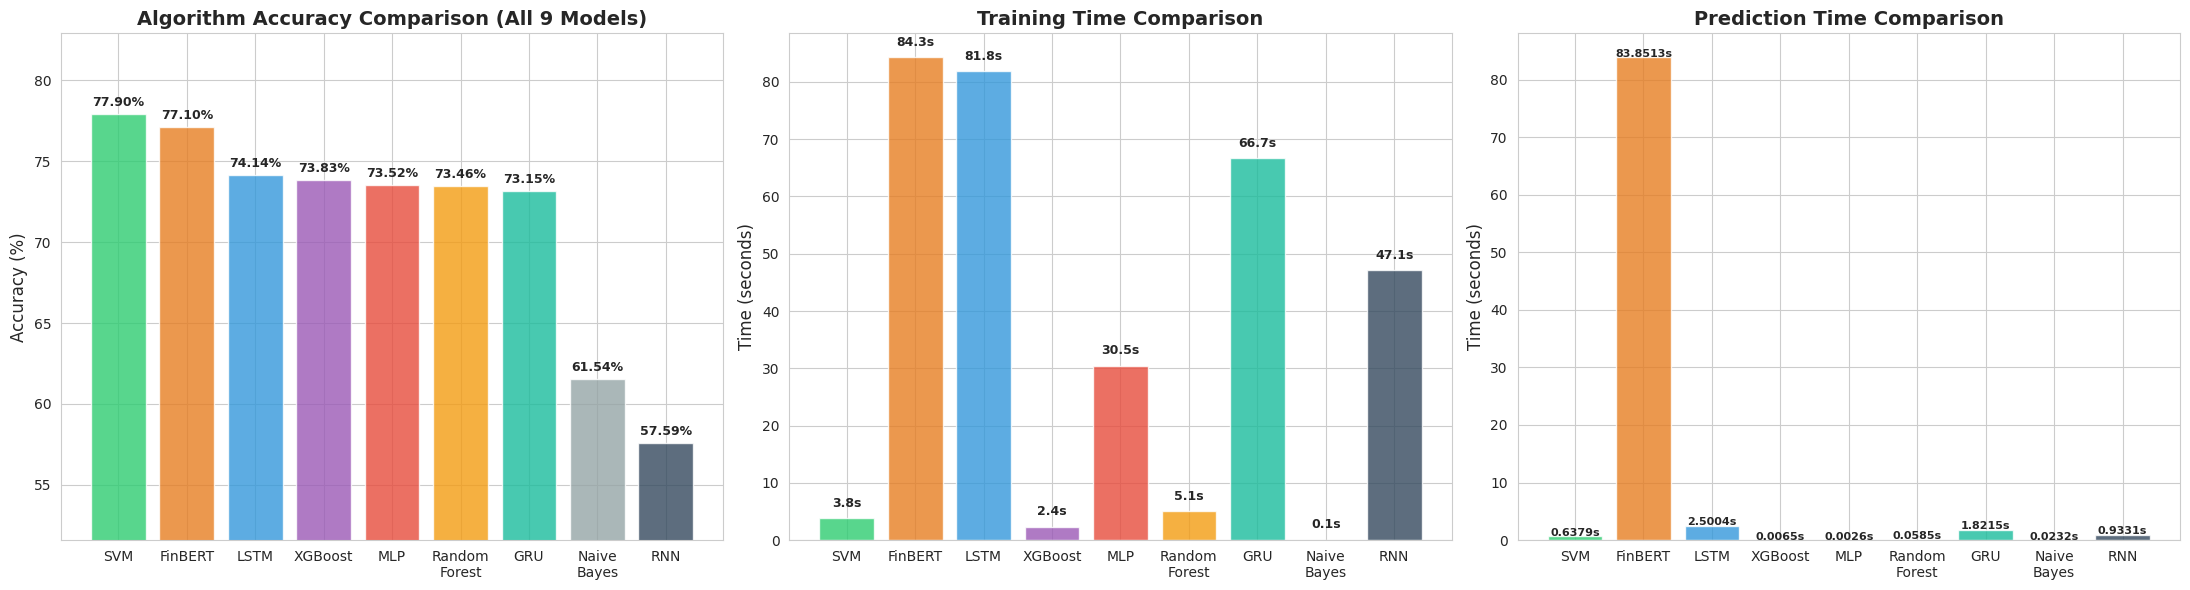

✅ Visualization saved as 'algorithm_comparison_all_9_models.png'


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot the table built in the cell above, so the chart and the table can never disagree.
algorithms = [a.replace(' ', '\n') for a in results_summary_complete['Algorithm']]
accuracies = results_summary_complete['Accuracy (%)'].tolist()
training_times = results_summary_complete['Training Time (s)'].tolist()
prediction_times = results_summary_complete['Prediction Time (s)'].tolist()

# Colors: 9 distinct colors
colors = ['#2ecc71', '#e67e22', '#3498db', '#9b59b6', '#e74c3c', '#f39c12', '#1abc9c', '#95a5a6', '#34495e']

# Subplot 1: Accuracy Comparison
axes[0].bar(algorithms, accuracies, color=colors, alpha=0.8)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Algorithm Accuracy Comparison (All 9 Models)', fontsize=14, fontweight='bold')
axes[0].set_ylim([min(accuracies) - 6, max(accuracies) + 5])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=9)

# Subplot 2: Training Time Comparison
axes[1].bar(algorithms, training_times, color=colors, alpha=0.8)
axes[1].set_ylabel('Time (seconds)', fontsize=12)
axes[1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(training_times):
    axes[1].text(i, v + 2, f'{v:.1f}s', ha='center', fontweight='bold', fontsize=9)

# Subplot 3: Prediction Time Comparison
axes[2].bar(algorithms, prediction_times, color=colors, alpha=0.8)
axes[2].set_ylabel('Time (seconds)', fontsize=12)
axes[2].set_title('Prediction Time Comparison', fontsize=14, fontweight='bold')
for i, v in enumerate(prediction_times):
    axes[2].text(i, v + 0.05, f'{v:.4f}s', ha='center', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.savefig('algorithm_comparison_all_9_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as 'algorithm_comparison_all_9_models.png'")

### Training Time against Accuracy

The cheapest model that is still accurate sits top-left.


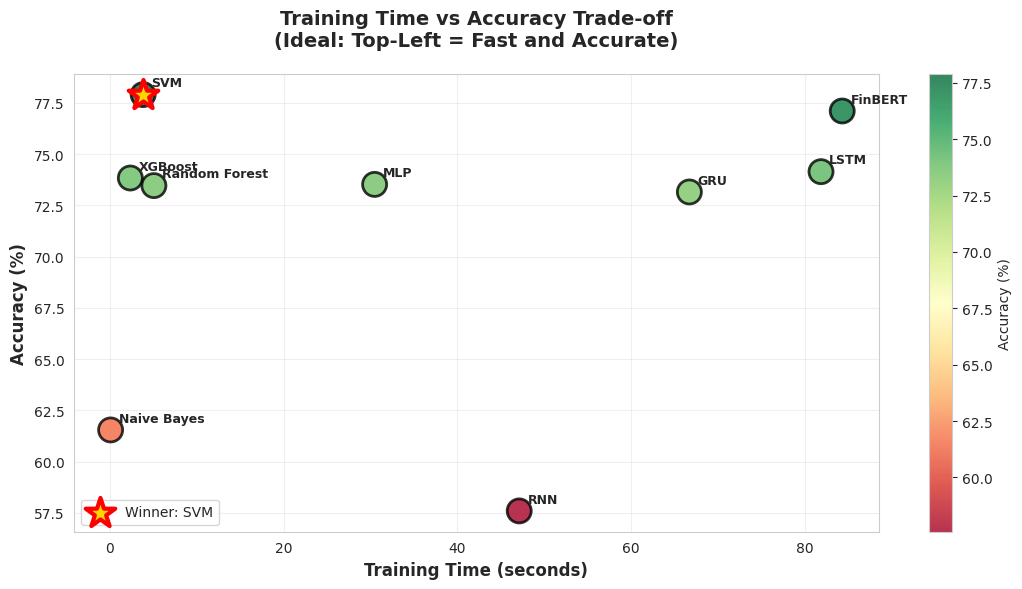

✅ Training time vs accuracy chart saved!


In [29]:
# Trade-off view: the cheapest model that is still accurate sits top-left.
plt.figure(figsize=(11, 6))

scatter = plt.scatter(
    results_summary_complete['Training Time (s)'],
    results_summary_complete['Accuracy (%)'],
    s=300,
    c=results_summary_complete['Accuracy (%)'],
    cmap='RdYlGn',
    edgecolors='black',
    linewidth=2,
    alpha=0.8
)

# Label every point with its algorithm
for idx, row in results_summary_complete.iterrows():
    plt.annotate(
        row['Algorithm'],
        (row['Training Time (s)'], row['Accuracy (%)']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Training Time vs Accuracy Trade-off\n(Ideal: Top-Left = Fast and Accurate)',
          fontsize=14, fontweight='bold', pad=20)
plt.colorbar(scatter, label='Accuracy (%)')
plt.grid(True, alpha=0.3)

# Mark the best model, read from the table rather than named by hand
winner = results_summary_complete.iloc[0]
plt.scatter(winner['Training Time (s)'], winner['Accuracy (%)'],
            s=500, marker='*', color='gold', edgecolors='red', linewidth=3,
            label=f"Winner: {winner['Algorithm']}", zorder=10)
plt.legend()

plt.tight_layout()
plt.savefig('training_time_vs_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training time vs accuracy chart saved!")


### Performance by Algorithm Family

Classical, feedforward, recurrent and transformer, side by side.


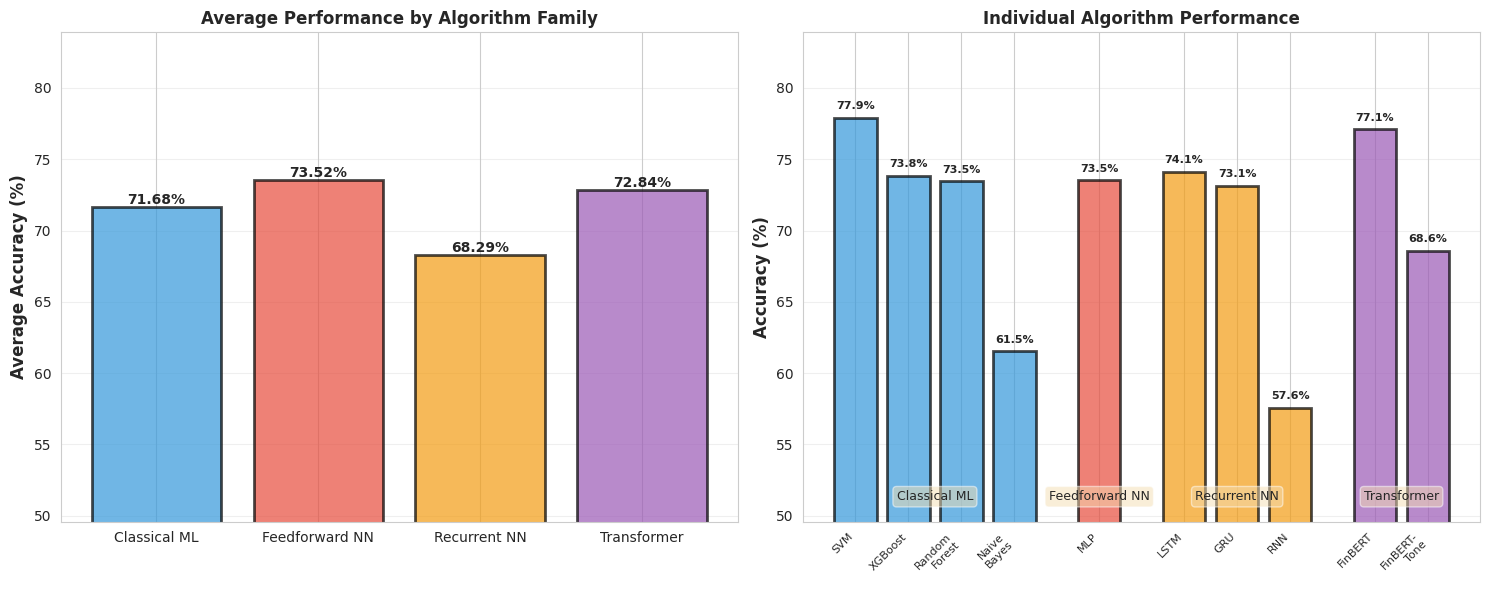

✅ Category comparison chart saved!


In [30]:
# Group every measured model by family. Accuracies come from the model variables,
# so this chart cannot disagree with the table above.
categories_data = {
    'Classical ML': {
        'algorithms': ['SVM', 'XGBoost', 'Random Forest', 'Naive Bayes'],
        'accuracies': [svm_accuracy * 100, xgb_accuracy * 100, rf_accuracy * 100, nb_accuracy * 100],
        'color': '#3498db'
    },
    'Feedforward NN': {
        'algorithms': ['MLP'],
        'accuracies': [mlp_accuracy * 100],
        'color': '#e74c3c'
    },
    'Recurrent NN': {
        'algorithms': ['LSTM', 'GRU', 'RNN'],
        'accuracies': [lstm_accuracy * 100, gru_accuracy * 100, rnn_accuracy * 100],
        'color': '#f39c12'
    },
    'Transformer': {
        'algorithms': ['FinBERT', 'FinBERT-Tone'],
        'accuracies': [finbert_accuracy * 100, finbert_tone_accuracy_corrected * 100],
        'color': '#9b59b6'
    }
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scale both panels to the measured range so nothing is clipped
_all_cat_acc = [a for d in categories_data.values() for a in d['accuracies']]
_lo, _hi = min(_all_cat_acc) - 8, max(_all_cat_acc) + 6

# Panel 1: average accuracy per family
categories = list(categories_data.keys())
avg_accuracies = [np.mean(data['accuracies']) for data in categories_data.values()]
colors_cat = [data['color'] for data in categories_data.values()]

bars = ax1.bar(categories, avg_accuracies, color=colors_cat, alpha=0.7, edgecolor='black', linewidth=2)
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}%',
             ha='center', va='bottom', fontweight='bold')

ax1.set_ylabel('Average Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Average Performance by Algorithm Family', fontsize=12, fontweight='bold')
ax1.set_ylim(_lo, _hi)
ax1.grid(axis='y', alpha=0.3)

# Panel 2: every model individually, grouped by family
x_pos = 0
xticks_pos, xticks_labels, band_centres = [], [], {}

for category, data in categories_data.items():
    start = x_pos
    for algo, acc in zip(data['algorithms'], data['accuracies']):
        ax2.bar(x_pos, acc, color=data['color'], alpha=0.7, edgecolor='black', linewidth=2)
        ax2.text(x_pos, acc + 0.6, f'{acc:.1f}%', ha='center', fontsize=8, fontweight='bold')
        xticks_pos.append(x_pos)
        xticks_labels.append(algo.replace(' ', '\n').replace('-', '-\n'))
        x_pos += 1
    band_centres[category] = (start + x_pos - 1) / 2
    x_pos += 0.6  # gap between families

ax2.set_xticks(xticks_pos)
ax2.set_xticklabels(xticks_labels, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Individual Algorithm Performance', fontsize=12, fontweight='bold')
ax2.set_ylim(_lo, _hi)
ax2.grid(axis='y', alpha=0.3)

for category, centre in band_centres.items():
    ax2.text(centre, _lo + 1.5, category, ha='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('algorithm_categories_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Category comparison chart saved!")


## Production Inference Pipeline - SVM Model

Demonstrating how to use the trained SVM model - the winner above - to classify unseen headlines.

In [31]:
# Test the inference pipeline with custom financial headlines
print("=" * 80)
print(f"INFERENCE PIPELINE DEMONSTRATION - SVM MODEL ({svm_accuracy*100:.2f}% Accuracy)")
print("=" * 80)

# Test Case 1: Positive sentiment
customText1 = "Tesla stock surges on strong Q4 earnings report"
customProcessed1 = text_processing(customText1)
custom_tfidf1 = vectorizer.transform([customProcessed1])
customPrediction1 = svm_model.predict(custom_tfidf1)

# Decode the prediction (remember: 0=negative, 1=neutral, 2=positive)
sentiment_label1 = le.inverse_transform(customPrediction1)[0]

print(f"\nTest 1:")
print(f"Input: {customText1}")
print(f"Preprocessed: {customProcessed1}")
print(f"Prediction: {sentiment_label1}")

# Test Case 2: Negative sentiment
customText2 = "Company reports massive losses and layoffs expected"
customProcessed2 = text_processing(customText2)
custom_tfidf2 = vectorizer.transform([customProcessed2])
customPrediction2 = svm_model.predict(custom_tfidf2)
sentiment_label2 = le.inverse_transform(customPrediction2)[0]

print(f"\nTest 2:")
print(f"Input: {customText2}")
print(f"Preprocessed: {customProcessed2}")
print(f"Prediction: {sentiment_label2}")

# Test Case 3: Neutral sentiment
customText3 = "Market remains stable with moderate trading volume"
customProcessed3 = text_processing(customText3)
custom_tfidf3 = vectorizer.transform([customProcessed3])
customPrediction3 = svm_model.predict(custom_tfidf3)
sentiment_label3 = le.inverse_transform(customPrediction3)[0]

print(f"\nTest 3:")
print(f"Input: {customText3}")
print(f"Preprocessed: {customProcessed3}")
print(f"Prediction: {sentiment_label3}")

print("=" * 80)
print("✅ Inference pipeline working.")
print("=" * 80)

INFERENCE PIPELINE DEMONSTRATION - SVM MODEL (77.90% Accuracy)

Test 1:
Input: Tesla stock surges on strong Q4 earnings report
Preprocessed: tesla stock surge strong q4 earnings report
Prediction: positive

Test 2:
Input: Company reports massive losses and layoffs expected
Preprocessed: company report massive loss layoff expected
Prediction: neutral

Test 3:
Input: Market remains stable with moderate trading volume
Preprocessed: market remains stable moderate trading volume
Prediction: positive
✅ Inference pipeline working.


### Adding Confidence Scores

The plain prediction above gives a label and nothing else, and some of those labels are wrong.
The decision score below shows how far from the boundary each prediction sits, which is what
tells you whether to trust it.


In [32]:
# Enhanced inference with confidence scores
print("\n" + "=" * 80)
print("ENHANCED INFERENCE - WITH CONFIDENCE SCORES")
print("=" * 80)

# Test with the questionable predictions
test_headlines = [
    "Tesla stock surges on strong Q4 earnings report",
    "Company reports massive losses and layoffs expected",
    "Market remains stable with moderate trading volume"
]

for headline in test_headlines:
    # Preprocess
    processed = text_processing(headline)
    
    # Vectorize
    tfidf = vectorizer.transform([processed])
    
    # Get prediction AND probabilities
    prediction = svm_model.predict(tfidf)[0]
    probabilities = svm_model.decision_function(tfidf)[0]
    
    # Decode sentiment
    sentiment = le.inverse_transform([prediction])[0]
    
    # Get confidence (highest decision function value)
    confidence = max(abs(probabilities))
    
    print(f"\nHeadline: {headline}")
    print(f"Prediction: {sentiment.upper()}")
    print(f"Confidence: {confidence:.2f}")
    print(f"Decision scores: neg={probabilities[0]:.2f}, neu={probabilities[1]:.2f}, pos={probabilities[2]:.2f}")


ENHANCED INFERENCE - WITH CONFIDENCE SCORES

Headline: Tesla stock surges on strong Q4 earnings report
Prediction: POSITIVE
Confidence: 2.23
Decision scores: neg=1.13, neu=-0.25, pos=2.23

Headline: Company reports massive losses and layoffs expected
Prediction: NEUTRAL
Confidence: 2.13
Decision scores: neg=1.09, neu=2.13, pos=-0.17

Headline: Market remains stable with moderate trading volume
Prediction: POSITIVE
Confidence: 2.07
Decision scores: neg=-0.06, neu=0.99, pos=2.07


---

# Conclusion: What I Learned from Testing 9 Machine Learning Algorithms

## The Goal

I wanted to find the best machine learning algorithm for analysing financial sentiment - basically, teaching a computer to read financial news headlines and figure out if they're positive, negative, or neutral.

Instead of just picking an algorithm based on theory or what others used, I decided to test them empirically (meaning: actually run the experiments and see what happens in practice).

**The Question:** Which algorithm works best for financial sentiment analysis when you have clean, real-world data?

## The Results: 9 Algorithms Tested

I tested nine algorithms on 8,100 balanced financial headlines. Same preprocessing, same
80/20 split, same seed. Accuracies below reproduce exactly on a re-run. Timings are in the
computed table above — they depend on the machine, so they are not repeated here.

### Final Rankings

| Rank | Algorithm | Accuracy | What It Is |
|------|-----------|----------|------------|
| 🥇 1st | SVM | 77.90% | Support Vector Machine - finds the best boundary between sentiments |
| 🥈 2nd | FinBERT | 77.10% | Transformer pre-trained on financial text, used zero-shot |
| 🥉 3rd | LSTM | 74.14% | Long Short-Term Memory - a recurrent network with memory gates |
| 4th | XGBoost | 73.83% | Gradient boosting - combines many weak predictions into one strong one |
| 5th | MLP | 73.52% | Multi-Layer Perceptron - a basic feedforward neural network |
| 6th | Random Forest | 73.46% | Many decision trees voting together |
| 7th | GRU | 73.15% | Gated Recurrent Unit - a simpler LSTM |
| 8th | Naive Bayes | 61.54% | Probability-based classifier, the baseline |
| 9th | RNN | 57.59% | Plain recurrent network, no gating |

A tenth model was tested as a variant: **FinBERT-Tone scored 68.58%** after its label encoding
was corrected. It is not ranked above because it is a second version of FinBERT rather than a
distinct algorithm.

**Winner: SVM at 77.90%, ahead of FinBERT by 0.80 percentage points** — and it trains in under
four seconds against FinBERT's eighty-plus.

Chance is 33.3%, because the classes were balanced deliberately.


## The Data Quality Discovery: Why Clean Data Matters

### What I Found

When I started this project I looked at other people's work on the same dataset to learn from
it. Their neural network numbers were much higher than mine.

**Published results on Financial PhraseBank:**
- Naive Bayes: 62%
- RNN: 77%
- LSTM: 79.8%
- GRU: 80.6%

**Mine:**
- Naive Bayes: 61.54% — matches
- RNN: 57.59% — far below
- LSTM: 74.14% — below
- GRU: 73.15% — below

The baseline matched and the neural networks did not. That pattern is the clue.

### The Investigation

**The problem was duplicate data.**

The original dataset had **504 duplicate sentences (5.6%)**, and some of those duplicates
carried *different labels*.

**Example:**
- "Finnish wood products company..." labelled **negative**
- "Finnish wood products company..." labelled **neutral**

Same sentence, two different "correct" answers.

### Why that inflates a neural network specifically

A duplicate can land in training and in test at the same time. A model with enough capacity
to memorise a sentence then gets it right in test because it has already seen it, not because
it generalised. Naive Bayes cannot memorise much, so duplicates barely help it. A recurrent
network can, so they help it a lot.

That is exactly the shape of my results: **the baseline matched published numbers and the
neural networks did not.**

### What others did, and what I did

**Common approach in the repositories I looked at:**
- Used the data as-is, duplicates included
- Some upsampled to balance the classes, which creates *more* duplicates on purpose

**Mine:**
1. Found the 504 duplicates
2. Removed them completely, keeping unique sentences only — 8,496 left
3. Downsampled each class to 2,700, giving 8,100 balanced samples
4. Downsampled rather than upsampled, because upsampling would put duplicates straight back in

### Why this matters

My neural network scores are lower because they are measured on data the models had not
already seen. I take the gap as evidence that the cleaning worked.


## Surprising Discoveries: What I Didn't Expect

### Surprise #1: Traditional ML beat the neural networks

**What I expected:** the neural networks would win.
**What happened:** SVM won, and the recurrent models finished 4th, 7th and 9th.

Neural networks need a lot of examples to learn from. Classical models need fewer.

- **My dataset:** 8,100 samples
- **What recurrent networks usually need:** tens of thousands
- **Result:** SVM and XGBoost outperformed them

**The insight:** more complex does not mean better. The right algorithm depends on how much
data you have, not on how modern the method is.

---

### Surprise #2: Gating is worth 16.55 percentage points

**The recurrent rankings:**

- RNN: 57.59%
- GRU: 73.15%
- LSTM: 74.14%

Same data, same preprocessing, same seed, same 5 epochs. The only thing that changed is the
recurrent cell.

Think of it as memory:

- **RNN:** loses the start of the sentence by the time it reaches the end
- **GRU:** keeps some of it, with two gates
- **LSTM:** keeps a separate memory it can write to and erase from, with three gates

Financial headlines need that:
- "Stock rose **despite** challenges" — needs both "rose" and "despite"
- "Strong earnings **but** missed forecasts" — two signals pulling opposite ways

**RNN to LSTM is a 16.55 point jump from architecture alone.**

Other researchers found GRU came out on top on this dataset. On my deduplicated version LSTM
did, but only by 0.99 points — close enough that I would not claim a real difference from one
run of each.

---

### Surprise #3: Cleaning the data helped classical models and hurt neural ones

**After removing duplicates, classical models improved:**
- SVM: 72.33% → 77.90%
- XGBoost: 69.78% → 73.83%

⚠ *The two "before" figures were measured on the uncleaned data in an earlier run. This
notebook loads the cleaned file directly, so it does not reproduce them. The "after" figures
are computed here.*

**The neural networks went the other way**, against published numbers on the uncleaned data:
- RNN: 77% published → 57.59% mine
- LSTM: 79.8% published → 74.14% mine

**Why this happens:**

It is the same mechanism as the duplicates finding. Classical models could not exploit the
duplicates much, so removing the conflicting labels left them with cleaner signal and they
improved. Neural networks could exploit duplicates, so removing them took away an easy win.

The lesson is not "clean data is bad for neural networks". It is that some of their published
advantage was never real.


## What This Means: Practical Takeaways

### Lesson 1: Check the data yourself

When I started I assumed published results were sound. Digging in showed that studies on this
dataset often do not check for duplicates, and some upsample without considering that it
duplicates rows on purpose.

**Takeaway:** inspect your own data. Published and clean are not the same thing.

---

### Lesson 2: The right amount of data depends on the model

- **Classical models:** did better on 8,100 clean samples than neural networks did
- **Neural networks:** need far more volume before their capacity pays off

There is no universal best. It depends on what you actually have.

---

### Lesson 3: Match the algorithm to the situation

**Under about 10,000 clean samples:**
- Use SVM, XGBoost or Random Forest
- Recurrent networks will probably underperform

**At tens of thousands of samples:**
- Recurrent networks and fine-tuned transformers become worth testing again

**If speed matters:**
- Naive Bayes: trains in under a tenth of a second, but only 61.54%
- XGBoost: trains in a couple of seconds for 73.83% — the best speed-to-accuracy trade here
- Avoid the recurrent models: roughly 45 to 85 seconds each

---

### Lesson 4: Architecture matters inside a family

Same data, same preprocessing, same parameters:
- RNN: 57.59%
- LSTM: 74.14%

**A 16.55 point difference from the recurrent cell alone.**

---

### Lesson 5: A score below chance means a bug

FinBERT-Tone first came out at **18.46%**, well under the 33.3% chance line. A model cannot
really be that much worse than guessing unless something is wired wrong. It was: the model
outputs Neutral/Positive/Negative, and I was scoring it against positive/negative/neutral.
Fixing the mapping moved it to **68.58%**.

That is 50 points of apparent model quality that was actually an indexing mistake.

---

### Lesson 6: Reproducibility is a property you have to add

The recurrent models had no random seed at first, so every run gave different numbers. Seeding
them was a three-line change and it is what makes the tables in this notebook trustworthy.
Every number here is computed when the notebook runs, not typed in.


## Final Recommendation: Which Algorithm Should You Use?

### For production: SVM

- **Best accuracy measured:** 77.90%
- **Fast to train:** under four seconds, against more than eighty for the LSTM
- **Works at this sample size:** does not need tens of thousands of rows
- **Interpretable:** you can see which words drove the prediction
- **CPU only:** no GPU required

**Worked example from the pipeline below:**
- Input: "Tesla stock surges on strong Q4 earnings report"
- Output: **positive**, decision score 2.23 (against 1.13 negative, −0.25 neutral)

---

### When to consider something else

**LSTM, if:**
- You can collect substantially more data
- Word order and contrast words matter more than they do here
- Eighty-odd seconds of training is acceptable

**XGBoost, if:**
- You want the fastest training of the accurate models, around two seconds
- 73.83% is good enough, four points behind SVM

**Naive Bayes, if:**
- Speed is the only priority — under a tenth of a second
- You can live with 61.54%

**FinBERT, if:**
- You can fine-tune it on your own domain data rather than using it zero-shot
- Note it was used here **without fine-tuning**, so 77.10% is its out-of-the-box score

---

### What about the recurrent networks?

Not yet worth it for this use case. They need more data than 8,100 samples, they take roughly
45 to 85 seconds to train, and the best of them still landed 3.76 points behind an SVM that
trains in under four seconds.

---

### The production pipeline

```
1. Input:          "Company reports strong quarterly earnings"
   ↓
2. Preprocessing:  lowercase, strip punctuation, tokenise, remove stopwords, lemmatise
   ↓
3. Vectorisation:  TF-IDF, 5,000 features
   ↓
4. SVM prediction
   ↓
5. Output:         "positive", with the decision score
```

The SVM classified all 1,620 test headlines in well under a second.


## Closing Thoughts

### What this comparison established

Nine algorithms, one dataset, identical preprocessing. **SVM won at 77.90%**, ahead of a
transformer pre-trained on financial text, and it trained in under four seconds.

**The lessons that generalise beyond this dataset:**

1. **Verify before trusting.** Published results on Financial PhraseBank were inflated by
   duplicate sentences. My baseline matched theirs; my neural networks did not. That gap is
   what pointed at the cause.
2. **Simpler can win.** A linear model on TF-IDF features beat FinBERT used zero-shot.
3. **Sample size decides which family to use.** At 8,100 samples the recurrent models were
   not competitive. That is about the data, not the architecture.
4. **Cleaning is not neutral.** Removing duplicates helped the classical models and took an
   unearned advantage away from the neural ones.
5. **A score below chance is a bug.** FinBERT-Tone at 18.46% was a label-order mistake worth
   50 points, not a bad model.
6. **Reproducibility has to be built in.** Unseeded models give a different answer every run,
   and a summary table typed by hand drifts away from the results it claims to report. Every
   figure and table here is computed when the notebook runs.

---

### How this differs from most comparison studies

Most of them test on a pre-cleaned dataset without checking it, do not investigate why their
numbers differ from anyone else's, and report a single unseeded run.

This one deduplicated first, chased down the disagreement with published results, balanced by
downsampling so duplicates could not return, tested nine algorithms across four families under
identical preprocessing, and seeds everything.

---

**MSc Programme:** Artificial Intelligence, University of Essex Online
**Work done:** November-December 2025
**Re-run with seeded models and computed result tables:** September 2026
